In [1]:
# pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image

✅ Dataset loaded. Total images: 20259


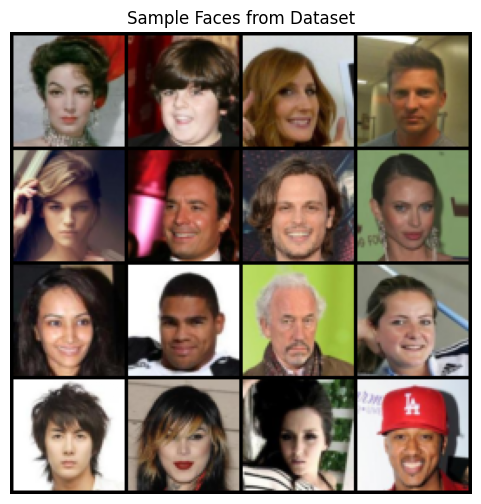

In [3]:

import os
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, datasets, utils
from PIL import Image
import matplotlib.pyplot as plt
import random

dataset_path = '/home/cse/Documents/NP/datasets/CelebA/img_align_celeba/img_align_celeba'


transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class FlatFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = [f for f in os.listdir(root_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.images[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 0

use_flat_folder = True

if use_flat_folder:
    dataset = FlatFaceDataset(dataset_path, transform)
else:
    dataset = datasets.ImageFolder(dataset_path, transform)

# 🔹 Create a subset (10%) of the dataset
subset_ratio = 0.1  # 10% subset
subset_size = int(len(dataset) * subset_ratio)
random.seed(42)  # For reproducibility
subset_indices = random.sample(range(len(dataset)), subset_size)
dataset = Subset(dataset, subset_indices)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

def show_images(batch):
    grid = utils.make_grid(batch, nrow=4, normalize=True)
    npimg = grid.permute(1, 2, 0).cpu().numpy()
    plt.figure(figsize=(6,6))
    plt.imshow(npimg)
    plt.axis('off')
    plt.title('Sample Faces from Dataset')
    plt.show()

if len(dataset) == 0:
    print("❌ Dataset not found or empty.")
else:
    print(f"✅ Dataset loaded. Total images: {len(dataset)}")
    images, _ = next(iter(dataloader))
    show_images(images)


In [4]:
image_size = 64
nz = 100  # Latent vector size
ngf = 64  # Generator feature map size
ndf = 64  # Discriminator feature map size
num_epochs = 50
batch_size = 128
lr = 0.0002
beta1 = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)


In [6]:

netG = Generator().to(device)
netD = Discriminator().to(device)

# Weight Initialization
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)

netG.apply(weights_init)
netD.apply(weights_init)

# ---------------------------
# Loss and Optimizers
# ---------------------------
criterion = nn.BCELoss()
optimizerD = torch.optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Fixed noise for monitoring
fixed_noise = torch.randn(64, nz, 1, 1, device=device)


In [7]:
import time
import os
import torchvision.utils as vutils


LATENT_DIM = 100
real_label = 1.
fake_label = 0.
EPOCHS = 50

if not os.path.exists('gan_images_pytorch'):
    os.makedirs('gan_images_pytorch')

img_list = []
G_losses = []
D_losses = []
iters = 0


fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)


for epoch in range(EPOCHS):
    start_time = time.time()

    for i, data in enumerate(dataloader, 0):
        netD.zero_grad()
        real_images = data[0].to(device)
        b_size = real_images.size(0)

        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output = netD(real_images).view(-1)
        lossD_real = criterion(output, label)
        lossD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=device)
        fake_images = netG(noise)
        label.fill_(fake_label)

        output = netD(fake_images.detach()).view(-1)
        lossD_fake = criterion(output, label)
        lossD_fake.backward()
        D_G_z1 = output.mean().item()

        lossD = lossD_real + lossD_fake
        optimizerD.step()

        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost

        output = netD(fake_images).view(-1)
        lossG = criterion(output, label)
        lossG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        # Save losses
        G_losses.append(lossG.item())
        D_losses.append(lossD.item())

        iters += 1

    # Generate and save image grid
    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
    grid_img = vutils.make_grid(fake, padding=2, normalize=True)
    img_list.append(grid_img)
    vutils.save_image(grid_img, f"gan_images_pytorch/epoch_{epoch+1}.png")
    
    torch.save(netG.state_dict(), "models/netG.pth")
    torch.save(netD.state_dict(), "models/netD.pth")

    # Epoch summary
    print(f"Epoch {epoch+1}/{EPOCHS} completed in {time.time()-start_time:.2f}s | "
          f"Loss_D: {lossD.item():.4f} | Loss_G: {lossG.item():.4f}")


Epoch 1/50 completed in 138.36s | Loss_D: 0.7864 | Loss_G: 1.6199
Epoch 2/50 completed in 138.35s | Loss_D: 0.2655 | Loss_G: 2.5953
Epoch 3/50 completed in 139.12s | Loss_D: 0.2321 | Loss_G: 3.9984
Epoch 4/50 completed in 139.89s | Loss_D: 0.6677 | Loss_G: 1.5737
Epoch 5/50 completed in 140.59s | Loss_D: 1.6370 | Loss_G: 10.6224
Epoch 6/50 completed in 139.26s | Loss_D: 1.1644 | Loss_G: 2.4792
Epoch 7/50 completed in 139.96s | Loss_D: 1.0128 | Loss_G: 2.7196
Epoch 8/50 completed in 139.62s | Loss_D: 0.1069 | Loss_G: 5.2439
Epoch 9/50 completed in 140.66s | Loss_D: 0.8484 | Loss_G: 9.2361
Epoch 10/50 completed in 139.97s | Loss_D: 0.3083 | Loss_G: 7.6085
Epoch 11/50 completed in 139.16s | Loss_D: 0.1136 | Loss_G: 4.6901
Epoch 12/50 completed in 139.49s | Loss_D: 0.4672 | Loss_G: 3.4174
Epoch 13/50 completed in 140.87s | Loss_D: 0.2528 | Loss_G: 4.2375
Epoch 14/50 completed in 139.43s | Loss_D: 0.7797 | Loss_G: 3.0875
Epoch 15/50 completed in 139.53s | Loss_D: 0.2124 | Loss_G: 5.5592
Epo

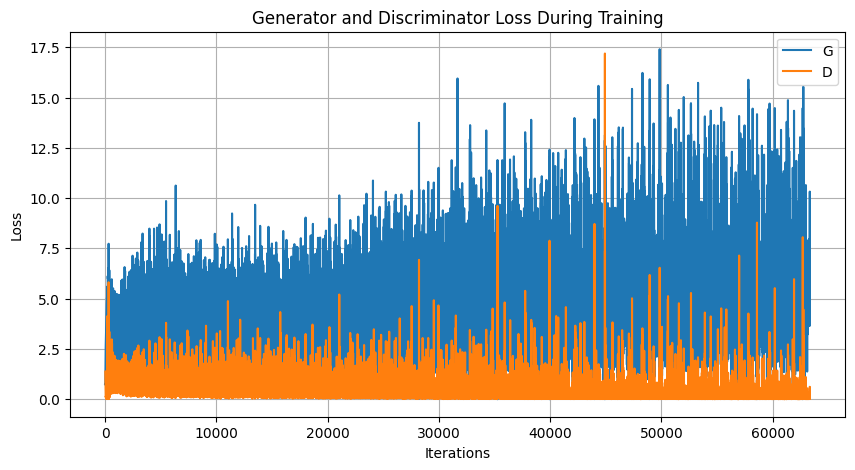

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


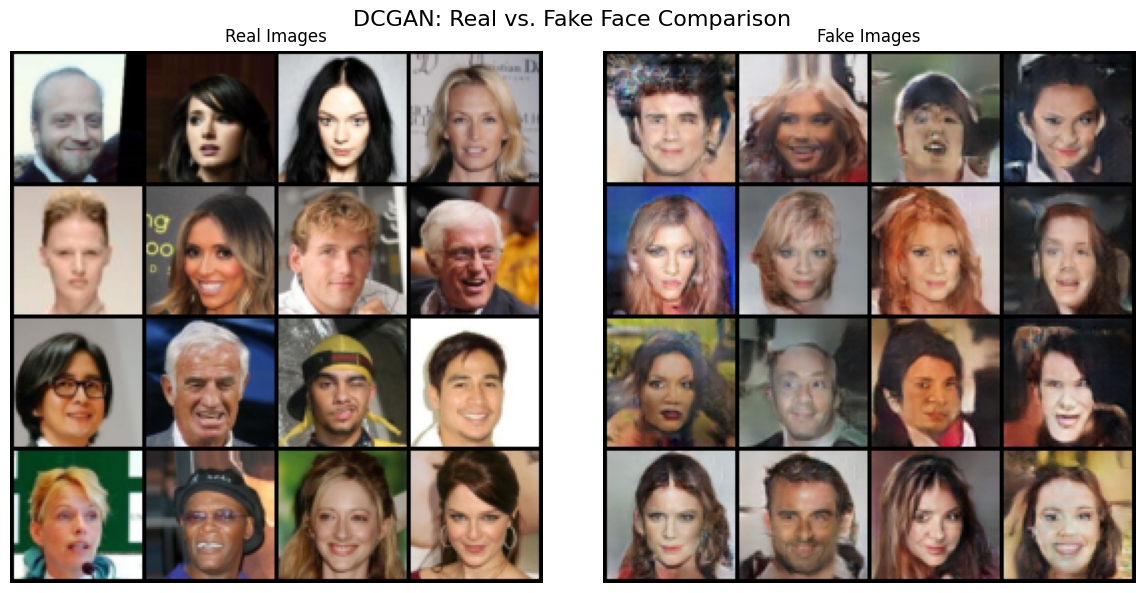

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np


real_batch = next(iter(dataloader))
with torch.no_grad():
    noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)
    fake_images = netG(noise).detach().cpu()
plt.figure(figsize=(12, 6))
plt.suptitle("DCGAN: Real vs. Fake Face Comparison", fontsize=16)

plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real Images")
real_grid = vutils.make_grid(real_batch[0][:16], nrow=4, padding=2, normalize=True)
plt.imshow(np.transpose(real_grid, (1, 2, 0)))

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Fake Images")
fake_grid = vutils.make_grid(fake_images, nrow=4, padding=2, normalize=True)
plt.imshow(np.transpose(fake_grid, (1, 2, 0)))

plt.tight_layout()
plt.show()